# Task 1 - Initial EDA: Brent Oil Prices

Quick look at the raw price series before we build the change point model in Task 2.

Goals for this notebook:
- Load and clean the data
- Check the trend visually
- Test for stationarity (raw price vs. log returns)
- Look at volatility clustering


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

from data_loader import load_raw_prices, add_log_returns

%matplotlib inline

## Load the data

In [2]:
df = load_raw_prices('../data/raw/BrentOilPrices.csv')
df = add_log_returns(df)

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Rows: 9011
Date range: 1987-05-20 to 2022-11-14


,Date,Price,log_price,log_return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


## Raw price over time

This is the plot we'll eventually overlay change points and events on.

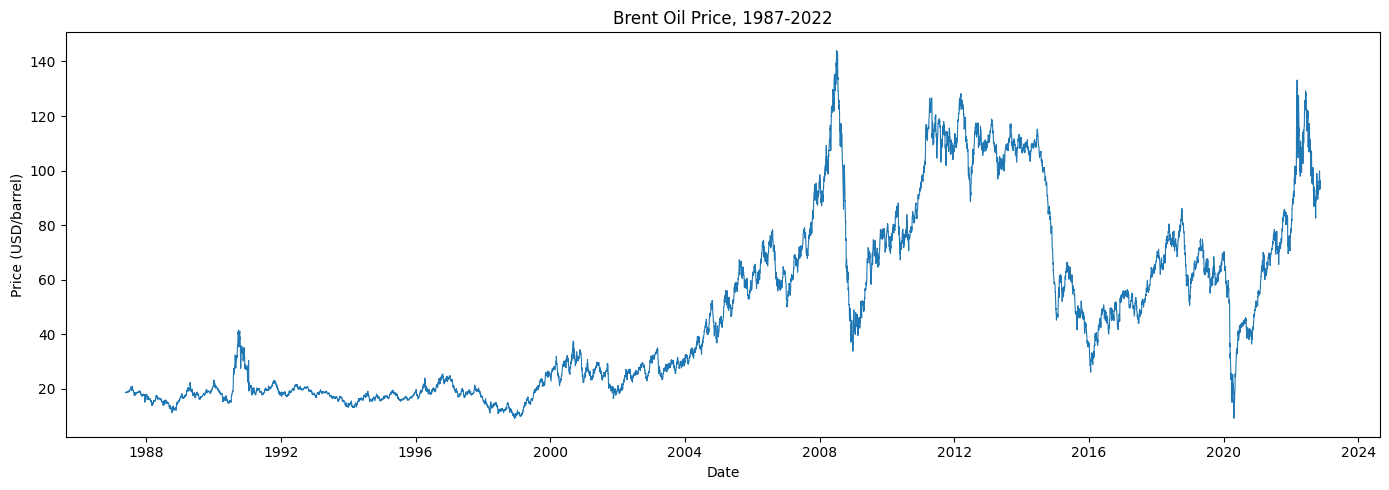

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['Price'], linewidth=0.8)
ax.set_title('Brent Oil Price, 1987-2022')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
plt.tight_layout()
plt.savefig('../data/processed/raw_price_plot.png', dpi=120)
plt.show()

Clear long-run swings here - the mid-2000s run-up, the 2008 crash, the 2014-16 collapse, the 2020 COVID crash, and the 2022 spike. This is not a series with one stable mean, which is exactly why a single fixed-parameter model won't work and we need change point detection.

## Stationarity check: raw price vs. log returns

Augmented Dickey-Fuller test. Null hypothesis is that the series has a unit root (i.e. is non-stationary).

In [4]:
adf_price = adfuller(df['Price'])
print(f"Raw price       -> ADF stat: {adf_price[0]:.3f}, p-value: {adf_price[1]:.4f}")

adf_returns = adfuller(df['log_return'].dropna())
print(f"Log returns     -> ADF stat: {adf_returns[0]:.3f}, p-value: {adf_returns[1]:.4f}")

Raw price       -> ADF stat: -1.994, p-value: 0.2893


Log returns     -> ADF stat: -16.427, p-value: 0.0000


Raw price has a p-value well above 0.05, so we can't reject the unit root - it's non-stationary, as expected for a price series with long trending regimes.

Log returns come back with a p-value near zero, so those are stationary. This confirms we should model **log returns**, not raw prices, in the Task 2 change point model.

## Log returns over time

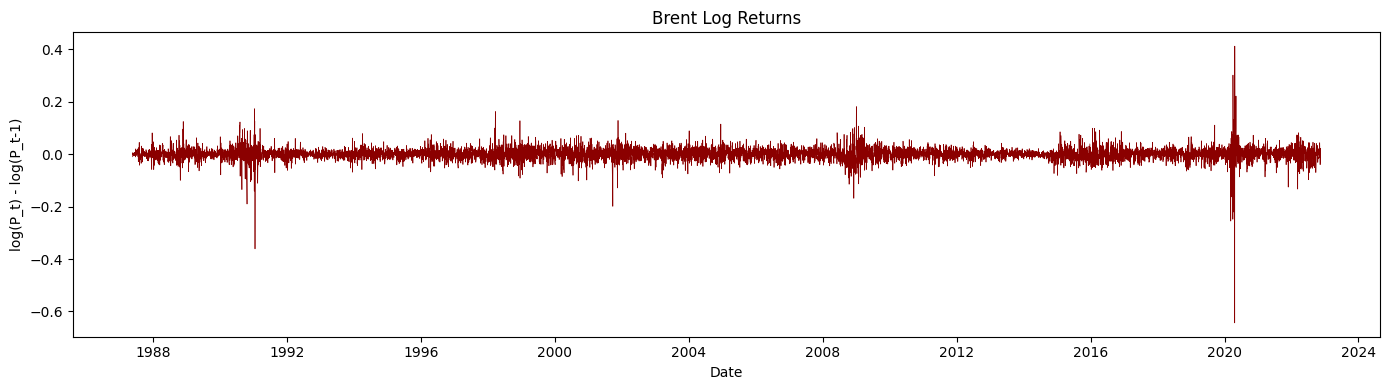

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['Date'], df['log_return'], linewidth=0.5, color='darkred')
ax.set_title('Brent Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('log(P_t) - log(P_t-1)')
plt.tight_layout()
plt.savefig('../data/processed/log_returns_plot.png', dpi=120)
plt.show()

## Volatility clustering

Rolling 30-day standard deviation of log returns - lets us see calm vs. turbulent periods.

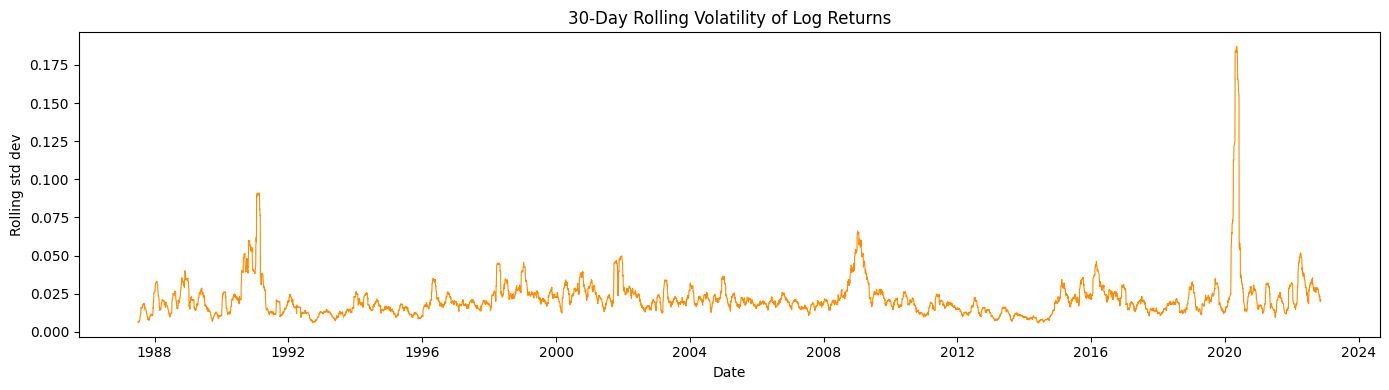

In [6]:
df['rolling_volatility_30d'] = df['log_return'].rolling(30).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['Date'], df['rolling_volatility_30d'], linewidth=0.8, color='darkorange')
ax.set_title('30-Day Rolling Volatility of Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling std dev')
plt.tight_layout()
plt.savefig('../data/processed/volatility_plot.png', dpi=120)
plt.show()

Volatility clearly clusters rather than staying flat - notice the spikes around 2008-09, 2014-16, and 2020. Calm periods and turbulent periods group together, which is a classic sign we might eventually want a variance change point too, not just a mean change point (see Task 2 'Advanced Extensions' for that idea).

## Summary of findings so far

- Raw prices are non-stationary and show multiple distinct regimes (multi-decade trend shifts)
- Log returns are approximately stationary (ADF confirms) - this is what we'll model in Task 2
- Volatility clusters over time rather than being constant - calm and turbulent regimes are visible
- These properties together justify a Bayesian change point approach on log returns rather than fitting one global mean/variance to the whole series